# 🟤 Copper Spot Price Forecasting — Kaggle Edition (Monthly)

**Monthly variant** of `copper_forecast_kaggle.ipynb`. Trains a multi-horizon
forecaster on **month-end** data going back to **1990-01-01** (~36 yrs of
observations). Targets: **1, 3, 6, 12 months ahead**.

### What is different vs the daily notebook
| Aspect | Daily notebook | This notebook |
|---|---|---|
| Calendar | Business-daily | Month-end |
| Start date | 2010-01-01 | **1990-01-01** |
| Horizons | 1 trading day | **1m, 3m, 6m, 12m** |
| CV | 504 / 22 (2y / 1mo, daily bars) | **120 / 3** (10y / 1q, monthly bars) |
| Holdout | 252 days (~1y) | **24 months** (2y) |
| Lags | [1, 5, 22] days | **[1, 3, 6, 12] months** |
| Annualisation | sqrt(252) | **sqrt(12)** |
| HMM regimes | 3 | **2** (~430 obs is thin) |
| Models | Naive, Linear, XGB, LGB, Prophet, Ensemble, Stacking | **ARIMAX, Prophet (yearly+multiplicative), Stacking (XGB+LGB+Prophet base)** |
| Prophet seasonality | weekly+yearly | **yearly only, multiplicative** |
| Extra signals | — | **NBS China PMI, China IP YoY, LME/SHFE Cu inventories, Chile Cu exports** |
| Output dir | `outputs_1d/` | **`outputs_monthly/`** |

### Prerequisites
| Setting | Value |
|---|---|
| **Accelerator** | GPU T4 x2 (XGB/LGB still benefit) |
| **Internet** | On |
| **Persistence** | Files only |
| **Secrets** | `FRED_API_KEY`, `EIA_API_KEY`, `ALPHA_VANTAGE_API_KEY`, `GMAIL_ADDRESS`, `GMAIL_APP_PASSWORD`, optionally `BCCH_API_KEY` |


## 0. Environment Setup

In [1]:
# ── Clone the repo (skip if already present) ──────────────────────────────
import os, subprocess, sys

REPO_URL  = 'https://github.com/ferhat00/copper-forecast.git'
REPO_DIR  = '/kaggle/working/copper-forecast'
BRANCH    = os.environ.get('REPO_BRANCH', 'main')


def _git(*args, cwd=None):
    out = subprocess.run(['git', *args], cwd=cwd, capture_output=True, text=True)
    if out.returncode != 0:
        raise RuntimeError(f"git {' '.join(args)} failed:\n{out.stderr}")
    return out.stdout


if not os.path.isdir(REPO_DIR):
    _git('clone', '--depth', '1', '--branch', BRANCH, REPO_URL, REPO_DIR)
    print(f'Cloned {BRANCH} OK')
else:
    print(f'Repo already present — fetching {BRANCH}…')
    _git('fetch', '--depth', '1', 'origin', BRANCH, cwd=REPO_DIR)
    _git('checkout', '-B', BRANCH, f'origin/{BRANCH}', cwd=REPO_DIR)
    print(f'On branch {BRANCH}, synced to origin/{BRANCH}.')

sha = _git('rev-parse', '--short', 'HEAD', cwd=REPO_DIR).strip()
print(f'HEAD: {BRANCH} @ {sha}')

os.chdir(REPO_DIR)
sys.path.insert(0, REPO_DIR)
print(f'Working directory: {os.getcwd()}')


Cloned main OK
HEAD: main @ 5895e3c
Working directory: /kaggle/working/copper-forecast


In [2]:
# ── Install / upgrade required packages ───────────────────────────────────
import subprocess, sys

_PKGS = [
    'yfinance>=0.2.36',
    'fredapi>=0.5.1',
    'prophet>=1.1.5',
    'hmmlearn>=0.3.0',
    'statsmodels>=0.14.0',
    'optuna>=3.4.0',
    'shap>=0.43.0',
    'kaleido==0.2.1',
    'akshare>=1.13.0',     # LME/SHFE inventories — graceful skip if install fails
    'pyyaml>=6.0',
]

subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '--quiet', '--upgrade'] + _PKGS,
    check=False,           # akshare may fail on Kaggle — we degrade gracefully
)
print('Packages installed (akshare optional — pipeline will skip inventory if absent).')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.7/133.7 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 80.3 MB/s eta 0:00:00
Packages installed (akshare optional — pipeline will skip inventory if absent).


In [3]:
!pip install plotly

In [4]:
# ── Detect GPU and configure accelerator flags ────────────────────────────
import subprocess

def _has_gpu() -> bool:
    try:
        out = subprocess.run(
            ['nvidia-smi', '--query-gpu=name', '--format=csv,noheader'],
            capture_output=True, text=True, timeout=5
        )
        return out.returncode == 0 and out.stdout.strip() != ''
    except FileNotFoundError:
        return False

GPU_AVAILABLE = _has_gpu()
XGB_DEVICE   = 'cuda' if GPU_AVAILABLE else 'cpu'
XGB_METHOD   = 'hist'
LGB_DEVICE   = 'gpu' if GPU_AVAILABLE else 'cpu'

import os
N_JOBS = int(os.cpu_count() or 2)

print(f'GPU available : {GPU_AVAILABLE}')
print(f'XGBoost device: {XGB_DEVICE} | tree_method: {XGB_METHOD}')
print(f'LightGBM device: {LGB_DEVICE}')
print(f'Parallel jobs : {N_JOBS}')


GPU available : False
XGBoost device: cpu | tree_method: hist
LightGBM device: cpu
Parallel jobs : 4


## 1. Setup & Configuration

In [5]:
import warnings
import logging
import numpy as np
import pandas as pd
import yaml

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(levelname)s | %(message)s')

from src.data_ingestion import load_data
from src.feature_engineering import build_features, split_features_targets
from src.models import (
    NaiveModel, LinearModel, XGBoostModel, LGBMModel, EnsembleModel,
    QuantileForecaster, BaseForecaster,
)
from src.models_stacking import StackingEnsemble
from src.evaluation import compute_metrics, walk_forward_cv, compare_models, out_of_sample_backtest
from src.visualization import (
    plot_price_history, plot_feature_correlations, plot_cv_results,
    plot_forecast_with_ci, plot_model_comparison, plot_shap_summary,
    plot_scenario_tornado, plot_dashboard, plot_regime_overlay,
)
from src.scenario_analysis import ScenarioEngine
from src.cointegration import add_cointegration_features
from src.regime_detection import RegimeDetector
from src.feature_pruning import auto_prune_features

try:
    from src.models_prophet import ProphetModel
    HAS_PROPHET = True
    print('✅ Prophet available')
except ImportError:
    HAS_PROPHET = False
    print('⚠️  Prophet not installed — ProphetModel will be skipped')

print('✅ All imports OK')


✅ Prophet available
✅ All imports OK


In [6]:
# ── Load API keys from Kaggle Secrets ───────────────────────────────────────
import os, shutil

try:
    from kaggle_secrets import UserSecretsClient
    _secrets = UserSecretsClient()
    for _key in ('EIA_API_KEY', 'FRED_API_KEY', 'ALPHA_VANTAGE_API_KEY', 'BCCH_API_KEY'):
        try:
            os.environ[_key] = _secrets.get_secret(_key)
            print(f'  Secret loaded: {_key}')
        except Exception:
            print(f'  WARNING: Secret not found: {_key}')
    print('API keys loaded.')
except ImportError:
    print('Not running on Kaggle — skipping secrets loader.')

# ── Locate the monthly config (private Kaggle dataset → repo fallback) ───────
REPO = '/kaggle/working/copper-forecast'
CONFIG_DATASET_PATH = '/kaggle/input/datasets/ferhat00/copper-monthlyv2/config_monthly.yaml'
CONFIG_DEST         = f'{REPO}/config_monthly.yaml'

if os.path.exists(CONFIG_DATASET_PATH):
    shutil.copy(CONFIG_DATASET_PATH, CONFIG_DEST)
    print(f'config_monthly.yaml copied from private dataset → {CONFIG_DEST}')
else:
    print(f'Using repo-bundled {CONFIG_DEST} (private dataset override not attached).')

with open(CONFIG_DEST) as _f:
    YCFG = yaml.safe_load(_f)
print('Loaded config keys:', sorted(YCFG.keys()))


API keys loaded.
config_monthly.yaml copied from private dataset → /kaggle/working/copper-forecast/config_monthly.yaml
Loaded config keys: ['alpha_vantage', 'bcch', 'cot', 'cv', 'data', 'eia', 'features', 'fred', 'market_tickers', 'sources']


In [7]:
# ── Build the runtime CFG dict from config_monthly.yaml ─────────────────────
CFG = {
    'start_date':           YCFG['data']['start_date'],
    'end_date':             YCFG['data'].get('end_date'),
    'freq':                 YCFG['data']['freq'],
    'horizons':             YCFG['features']['horizons'],
    'primary_horizon':      YCFG['features'].get('primary_horizon', 3),
    'lags':                 YCFG['features']['lags'],
    'return_lags':          YCFG['features']['return_lags'],
    'vol_windows':          YCFG['features']['vol_windows'],
    'ma_window':            YCFG['features']['ma_window'],
    'annualisation_factor': YCFG['features']['annualisation_factor'],
    'yoy_periods':          YCFG['features']['yoy_periods'],
    'include_intraday':     YCFG['features']['include_intraday'],
    'horizon_unit':         YCFG['features']['horizon_unit'],

    'initial_train_size':   YCFG['cv']['initial_train_size'],
    'cv_step_size':         YCFG['cv']['step_size'],
    'rolling_window':       YCFG['cv'].get('rolling_window'),
    'holdout_size':         YCFG['cv']['holdout_months'],
    'periods_per_year':     12,
    'ci_alpha':             0.80,

    # Optuna budget — monthly fits are sub-second per trial
    'optuna_trials':        100,
    'xgb_device':           XGB_DEVICE,
    'xgb_tree_method':      XGB_METHOD,
    'lgb_device':           LGB_DEVICE,

    # Sources
    'include_lme_inventory':  YCFG['sources'].get('lme_inventory', False),
    'include_shfe_inventory': YCFG['sources'].get('shfe_inventory', False),
    'include_chile_supply':   YCFG['sources'].get('chile_supply', False),

    # API keys
    'fred_api_key':           os.environ.get('FRED_API_KEY')          or YCFG.get('fred', {}).get('api_key'),
    'eia_api_key':            os.environ.get('EIA_API_KEY')           or YCFG.get('eia', {}).get('api_key'),
    'alpha_vantage_api_key':  os.environ.get('ALPHA_VANTAGE_API_KEY') or YCFG.get('alpha_vantage', {}).get('api_key'),
    'bcch_api_key':           os.environ.get('BCCH_API_KEY')          or YCFG.get('bcch', {}).get('api_key'),

    'random_seed':          42,
    'output_dir':           '/kaggle/working/outputs_monthly',
}
os.makedirs(CFG['output_dir'], exist_ok=True)
print('Configuration set:')
for k, v in CFG.items():
    if 'key' not in k or not v:
        print(f'  {k}: {v}')
    else:
        print(f'  {k}: ***')


Configuration set:
  start_date: 1990-01-01
  end_date: None
  freq: M
  horizons: [1, 3, 6, 12]
  primary_horizon: 3
  lags: [1, 3, 6, 12]
  return_lags: [1, 3, 6, 12]
  vol_windows: [3, 6, 12]
  ma_window: 24
  annualisation_factor: 3.4641016151377544
  yoy_periods: 12
  include_intraday: False
  horizon_unit: m
  initial_train_size: 60
  cv_step_size: 3
  rolling_window: 120
  holdout_size: 24
  periods_per_year: 12
  ci_alpha: 0.8
  optuna_trials: 100
  xgb_device: cpu
  xgb_tree_method: hist
  lgb_device: cpu
  include_lme_inventory: True
  include_shfe_inventory: True
  include_chile_supply: False
  fred_api_key: ***
  eia_api_key: ***
  alpha_vantage_api_key: ***
  bcch_api_key: 
  random_seed: 42
  output_dir: /kaggle/working/outputs_monthly


## 2. Data Ingestion (Monthly)

`load_data(freq="M")` resamples daily yfinance prices to month-end (last) and
yield/spread/rate columns to monthly mean. FRED, Alpha Vantage, EIA, LME/SHFE
inventories, and Chile copper exports are all aligned to the same month-end
calendar with publication-lag shifts converted from business days to whole
months.

In [8]:
import pickle, hashlib, time

# Cache key — change if you want to force a refresh
_cache_inputs = (
    CFG['start_date'] + str(CFG['fred_api_key']) + str(CFG['eia_api_key']) +
    str(CFG['alpha_vantage_api_key']) + str(CFG['include_lme_inventory']) +
    str(CFG['include_shfe_inventory']) + str(CFG['include_chile_supply'])
)
_cache_key  = hashlib.md5(_cache_inputs.encode()).hexdigest()[:8]
_cache_path = f"/kaggle/working/data_cache_monthly_{_cache_key}.pkl"

if os.path.exists(_cache_path):
    print(f'Loading cached data from {_cache_path}…')
    with open(_cache_path, 'rb') as _f:
        df_raw = pickle.load(_f)
    print('  Cache hit.')
else:
    print('Downloading data (first run — will be cached afterwards)…')
    _t0 = time.time()
    df_raw = load_data(
        start=CFG['start_date'],
        end=CFG['end_date'],
        fred_api_key=CFG['fred_api_key'],
        eia_api_key=CFG['eia_api_key'],
        alpha_vantage_api_key=CFG['alpha_vantage_api_key'],
        bcch_api_key=CFG['bcch_api_key'],
        include_cot=False,                     # CFTC COT is daily-only
        freq=CFG['freq'],
        include_lme_inventory=CFG['include_lme_inventory'],
        include_shfe_inventory=CFG['include_shfe_inventory'],
        include_chile_supply=CFG['include_chile_supply'],
    )
    with open(_cache_path, 'wb') as _f:
        pickle.dump(df_raw, _f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f'  Downloaded in {time.time()-_t0:.1f}s — cached to {_cache_path}')

print(f'Dataset shape: {df_raw.shape}')
print(f'Date range: {df_raw.index.min().date()} → {df_raw.index.max().date()}')
print(f'Frequency  : month-end (rows are calendar months)')
df_raw.tail()


ERROR | $NILSY: possibly delisted; no timezone found
ERROR | HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: GOGL"}}}
ERROR | $GOGL: possibly delisted; no timezone found
ERROR | $ARCH: possibly delisted; no timezone found
ERROR | $X: possibly delisted; no timezone found
ERROR | 
4 Failed downloads:
ERROR | ['NILSY', 'GOGL', 'ARCH', 'X']: possibly delisted; no timezone found
INFO | yfinance: downloaded 9473 rows for 105 tickers
INFO | FRED: fetched INDPRO (435 obs)
INFO | FRED: fetched IPMAN (435 obs)
INFO | FRED: fetched TCU (435 obs)
WARNING | FRED: could not fetch MCUMFNS — Bad Request.  The series does not exist.
INFO | FRED: fetched HOUST (433 obs)
INFO | FRED: fetched PERMIT (433 obs)
INFO | FRED: fetched TTLCONS (397 obs)
INFO | FRED: fetched TLRESCONS (289 obs)
INFO | FRED: fetched MANEMP (435 obs)
INFO | FRED: fetched AMTMNO (409 obs)
INFO | FRED: fetched AMTMUO (410 obs)
INFO | FRED: fetched DGORDER (434 obs

  Downloaded in 96.4s — cached to /kaggle/working/data_cache_monthly_27f4054b.pkl
Dataset shape: (309, 147)
Date range: 2000-08-31 → 2026-04-30
Frequency  : month-end (rows are calendar months)


,shanghai,alcoa,agnico,aluminium,coal_amr,antofagasta,coal_arch,aud_usd,dry_bulk_etf,bhp,...,labor_force_part,retail_sales,consumer_sentiment,inventory_sales,wti_spot,nat_gas_spot,copper_lme_monthly,china_mfg_prod,av_copper,av_aluminum
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-31,3968.840088,53.053112,169.226791,2906.25,199.880005,44.360001,NaN,0.669800,8.77,59.204124,...,62.5,634477.0,51.0,1.37,57.26,4.00,10739.918261,NaN,9994.773182,2654.479091
2026-01-31,4117.948242,56.717113,190.159286,3034.50,209.800003,50.490002,NaN,0.704730,11.53,67.402679,...,62.4,634830.0,52.9,1.38,64.50,7.18,10812.028000,NaN,10739.918261,2793.086957
2026-02-28,4162.880859,61.978497,251.150009,3044.25,162.649994,58.110001,NaN,0.710180,12.07,79.994705,...,62.1,634949.0,56.4,1.37,66.96,2.99,11790.964091,NaN,10812.028000,2819.061500
2026-03-31,3891.861084,66.330002,202.979996,3405.50,205.270004,44.570000,NaN,0.684590,9.97,72.739998,...,62.0,639691.0,56.6,1.36,102.86,2.88,12986.606818,NaN,11790.964091,2875.897727
2026-04-30,4079.899902,66.010002,200.229996,3555.75,187.229996,50.599998,NaN,0.712962,10.90,79.820000,...,61.9,651843.0,53.3,1.35,91.06,2.81,12951.345000,NaN,12986.606818,3133.982727


In [9]:
df_raw.describe().round(2)

,shanghai,alcoa,agnico,aluminium,coal_amr,antofagasta,coal_arch,aud_usd,dry_bulk_etf,bhp,...,labor_force_part,retail_sales,consumer_sentiment,inventory_sales,wti_spot,nat_gas_spot,copper_lme_monthly,china_mfg_prod,av_copper,av_aluminum
count,309.00,309.00,309.00,144.00,63.00,196.00,0.0,240.00,98.00,309.00,...,309.00,309.00,309.00,309.00,309.00,309.00,309.00,226.00,309.00,309.00
mean,2678.78,39.59,40.01,2229.32,163.54,14.36,NaN,0.79,13.31,25.96,...,64.10,391669.61,81.10,1.35,64.97,4.31,6221.08,1.10,6184.94,2028.36
std,868.43,18.01,32.95,420.23,91.96,8.49,NaN,0.13,7.34,16.44,...,1.74,115500.23,13.67,0.07,24.62,2.22,2606.80,0.89,2590.55,460.81
min,1060.74,5.87,3.99,1491.25,11.48,4.09,NaN,0.62,4.65,2.17,...,60.10,240979.00,50.00,1.24,19.23,1.54,1377.38,-2.98,1377.38,1283.53
25%,2033.31,24.26,22.01,1860.19,119.71,9.25,NaN,0.70,7.72,13.84,...,62.70,304187.00,70.80,1.29,47.26,2.81,4641.97,0.62,4638.83,1685.22
50%,2847.42,35.47,37.07,2243.38,159.21,11.29,NaN,0.76,10.97,25.53,...,63.40,364181.00,82.50,1.35,64.87,3.66,6712.85,1.11,6704.90,1946.19
75%,3252.20,55.31,48.17,2449.38,206.79,17.54,NaN,0.89,18.29,32.83,...,66.00,444555.00,92.60,1.40,81.80,5.35,8061.92,1.57,8060.92,2382.83
max,5954.77,86.14,251.15,3555.75,399.24,58.11,NaN,1.10,36.01,79.99,...,67.20,651843.00,108.30,1.74,139.96,14.84,12986.61,4.97,12986.61,3498.37


In [10]:
missing = df_raw.isna().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
audit = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print('Missing data audit (top 25):')
top_missing = audit[audit['missing_count'] > 0].sort_values('missing_count', ascending=False).head(25)
print(top_missing.to_string() if len(top_missing) else 'No missing data')


Missing data audit (top 25):
                   missing_count  missing_pct
coal_arch                    309        100.0
us_steel                     309        100.0
norilsk                      309        100.0
golden_ocean                 309        100.0
usd_cnh                      308         99.7
eagle_bulk                   296         95.8
ig_oas                       272         88.0
hy_oas                       272         88.0
coal_amr                     246         79.6
zim                          245         79.3
uranium_miners               232         75.1
dry_bulk_etf                 211         68.3
ero_copper                   206         66.7
coal_btu                     200         64.7
anglo_american               174         56.3
commodity_broad2             171         55.3
genco                        167         54.0
aluminium                    165         53.4
ivanhoe                      146         47.2
glencore                     138         44.7
globa

## 3. Exploratory Data Analysis

In [11]:
fig_price = plot_price_history(df_raw)
fig_price.show()


In [12]:
import plotly.express as px

corr_all = df_raw.corr()['copper_price'].drop('copper_price').sort_values()
fig_corr_bar = px.bar(
    x=corr_all.values, y=corr_all.index, orientation='h',
    title='Pearson Correlation with Copper Price (monthly)',
    labels={'x': 'Pearson r', 'y': 'Series'},
    template='plotly_white', color=corr_all.values,
    color_continuous_scale='RdBu', color_continuous_midpoint=0,
)
fig_corr_bar.show()


In [13]:
import plotly.graph_objects as go

monthly_ret = np.log(df_raw['copper_price'] / df_raw['copper_price'].shift(1)).dropna()
fig_dist = go.Figure()
fig_dist.add_trace(go.Histogram(
    x=monthly_ret, nbinsx=60, name='Monthly log return',
    marker_color='#b87333', opacity=0.75,
))
fig_dist.update_layout(
    title='Distribution of Monthly Copper Log Returns (1990 →)',
    xaxis_title='Log Return', yaxis_title='Count',
    template='plotly_white',
)
fig_dist.show()
print(f'Skewness: {monthly_ret.skew():.3f}  |  Kurtosis: {monthly_ret.kurt():.3f}')
print(f'Annualised volatility (sqrt(12)): {monthly_ret.std() * np.sqrt(12):.1%}')


Skewness: -0.683  |  Kurtosis: 5.113
Annualised volatility (sqrt(12)): 25.6%


## 4. Cointegration Analysis & Regime Detection (2-state HMM)

In [14]:
df_aug, coint_results = add_cointegration_features(df_raw)

coint_df = pd.DataFrame(coint_results).T
print('── Cointegration Test Results (Engle-Granger, monthly bars) ──')
print(coint_df.to_string())
print(f'\nCointegrated pairs: {[k for k, v in coint_results.items() if v["is_cointegrated"]]}')
print(f'ECT columns added: {[c for c in df_aug.columns if c.startswith("ect_")]}')


INFO | Cointegration test: t=-2.983  p=0.1143  beta=2.6115  cointegrated=False
INFO | Cointegration test: t=-3.048  p=0.0992  beta=4.1421  cointegrated=False
INFO | Cointegration: column 'oil' not in DataFrame, skipping
INFO | Cointegration test: t=-0.640  p=0.9528  beta=-69.4783  cointegrated=False
INFO | Cointegration: column 'cny_usd' not in DataFrame, skipping


── Cointegration Test Results (Engle-Granger, monthly bars) ──
              column is_cointegrated   p_value       beta
gold            gold           False    0.1143   2.611546
aluminium  aluminium           False  0.099154    4.14213
dxy              dxy           False  0.952766 -69.478261

Cointegrated pairs: []
ECT columns added: []


In [15]:
# Build a preliminary feature matrix to fit the regime detector
feats_prelim = build_features(
    df_aug,
    lags=CFG['lags'],
    horizons=CFG['horizons'],
    return_lags=CFG['return_lags'],
    vol_windows=CFG['vol_windows'],
    ma_window=CFG['ma_window'],
    annualisation_factor=CFG['annualisation_factor'],
    yoy_periods=CFG['yoy_periods'],
    include_intraday=CFG['include_intraday'],
    horizon_unit=CFG['horizon_unit'],
)

n_holdout = CFG['holdout_size']
# 2-state HMM: ~430 monthly observations is too few for 3-state diagonal-cov fits
regime_detector = RegimeDetector(n_regimes=2)

try:
    regime_detector.fit(feats_prelim.iloc[:-n_holdout])
    regime_labels = regime_detector.predict(feats_prelim)
    print(f'Regime distribution:\n{regime_labels.value_counts().sort_index()}')
    fig_regime = plot_regime_overlay(df_aug['copper_price'], regime_labels)
    fig_regime.show()
except ImportError:
    print('⚠️  hmmlearn not installed — regime detection skipped')
    regime_labels = None
except Exception as e:
    print(f'⚠️  Regime detection failed: {e}')
    regime_labels = None


⚠️  Regime detection failed: None of the regime features ['copper_ret_1d', 'copper_vol_22d', 'copper_zscore_200d'] found in X columns


## 5. Feature Engineering

In [16]:
feats = build_features(
    df_aug,
    lags=CFG['lags'],
    horizons=CFG['horizons'],
    return_lags=CFG['return_lags'],
    vol_windows=CFG['vol_windows'],
    ma_window=CFG['ma_window'],
    annualisation_factor=CFG['annualisation_factor'],
    yoy_periods=CFG['yoy_periods'],
    include_intraday=CFG['include_intraday'],
    horizon_unit=CFG['horizon_unit'],
)

if regime_labels is not None:
    feats['regime'] = regime_labels.reindex(feats.index)
    for i in range(2):
        feats[f'regime_{i}'] = (feats['regime'] == i).astype(float)

print(f'Feature matrix shape: {feats.shape}')
feat_cols = [c for c in feats.columns if not c.startswith('target_') and c != 'copper_price']
print(f'Total features (incl. lags): {len(feat_cols)}')

# Verify the target columns are stamped with the monthly suffix
assert any(c == f"target_ret_{CFG['primary_horizon']}m" for c in feats.columns), (
    f"Expected target_ret_{CFG['primary_horizon']}m in feature matrix; got {[c for c in feats.columns if c.startswith('target_ret_')]}"
)
print('Target columns:', [c for c in feats.columns if c.startswith('target_ret_')])

X, y_ret, y_price = split_features_targets(
    feats,
    horizon=CFG['primary_horizon'],
    horizon_unit=CFG['horizon_unit'],
)
print(f'X: {X.shape}  |  y: {y_ret.shape}')
print(f'Date range: {X.index.min().date()} → {X.index.max().date()}')


Feature matrix shape: (309, 149)
Total features (incl. lags): 140
Target columns: ['target_ret_1m', 'target_ret_3m', 'target_ret_6m', 'target_ret_12m']
X: (129, 140)  |  y: (129,)
Date range: 2015-05-31 → 2026-01-31


In [17]:
fig_feat_corr = plot_feature_correlations(X, y_ret, top_n=25)
fig_feat_corr.show()


## 6. Model Training & Hyper-parameter Tuning

For monthly bars (~430 obs), we use:
- **ARIMAX** (statsmodels SARIMAX wrapper, exogenous features), classical baseline
- **Prophet** with `yearly_seasonality=True`, `weekly_seasonality=False`,
  `daily_seasonality=False`, `seasonality_mode='multiplicative'`
- **Stacked ensemble** of XGBoost + LightGBM + Prophet via OOF stacking

Naive and Linear are also evaluated as benchmarks.

In [18]:
# ── ARIMAX wrapper (statsmodels SARIMAX with exogenous regressors) ─────────
# Defined inline because it's used only by the monthly notebook. Conforms to the
# BaseForecaster interface via .fit() / .predict() / .name.
import warnings as _warn
from statsmodels.tsa.statespace.sarimax import SARIMAX


class ARIMAXModel(BaseForecaster):
    """SARIMAX(p, d, q) wrapper with exogenous features. Robust to fit failures."""

    def __init__(self, order=(1, 0, 1), max_exog: int = 12):
        self.order = order
        self.max_exog = max_exog
        self._fit = None
        self._exog_cols: list = []

    @property
    def name(self) -> str:
        p, d, q = self.order
        return f'ARIMAX({p},{d},{q})'

    def _select_exog(self, X: pd.DataFrame, y: pd.Series) -> list:
        # Pick the top-k exogenous features by absolute Pearson correlation with y.
        # Avoids the SARIMAX MLE fit blowing up on high-dim near-collinear inputs.
        candidates = [c for c in X.columns if X[c].notna().sum() > len(X) * 0.5]
        if not candidates:
            return []
        ranked = (X[candidates].apply(lambda s: s.corr(y))
                  .abs().sort_values(ascending=False).head(self.max_exog))
        return ranked.index.tolist()

    def fit(self, X: pd.DataFrame, y: pd.Series) -> 'ARIMAXModel':
        self._exog_cols = self._select_exog(X, y)
        exog = X[self._exog_cols].fillna(0.0).values if self._exog_cols else None
        with _warn.catch_warnings():
            _warn.simplefilter('ignore')
            try:
                model = SARIMAX(
                    y.values, exog=exog, order=self.order,
                    enforce_stationarity=False, enforce_invertibility=False,
                )
                self._fit = model.fit(disp=False, maxiter=200)
            except Exception as exc:
                print(f'  ARIMAX fit failed ({exc}); falling back to zero predictions')
                self._fit = None
        return self

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        if self._fit is None:
            return np.zeros(len(X))
        exog = X[self._exog_cols].fillna(0.0).values if self._exog_cols else None
        try:
            steps = len(X)
            fc = self._fit.get_forecast(steps=steps, exog=exog)
            return np.asarray(fc.predicted_mean, dtype=float)
        except Exception:
            return np.zeros(len(X))


print('ARIMAX wrapper defined.')


ARIMAX wrapper defined.


In [19]:
# ── GPU/CPU flags injected into XGB / LGB params ─────────────────────────
_xgb_params = {**XGBoostModel.DEFAULT_PARAMS, 'device': CFG['xgb_device'], 'tree_method': CFG['xgb_tree_method']}
_lgb_params = {**LGBMModel.DEFAULT_PARAMS,    'device': CFG['lgb_device']}

def make_xgb(): return XGBoostModel(params=_xgb_params.copy())
def make_lgb(): return LGBMModel(params=_lgb_params.copy())
def make_arimax(): return ARIMAXModel(order=(1, 0, 1))
def make_prophet():
    return ProphetModel(
        weekly_seasonality=False,
        daily_seasonality=False,
        yearly_seasonality=True,
        seasonality_mode='multiplicative',
    ) if HAS_PROPHET else None

# Holdout split — last 24 months
X_dev,  y_dev   = X.iloc[:-n_holdout], y_ret.iloc[:-n_holdout]
X_hold, y_hold  = X.iloc[-n_holdout:], y_ret.iloc[-n_holdout:]
price_hold      = y_price.iloc[-n_holdout:]

print(f'Development set : {len(X_dev)} months')
print(f'Holdout set     : {len(X_hold)} months')
print(f'Dev range       : {X_dev.index.min().date()} → {X_dev.index.max().date()}')
print(f'Holdout range   : {X_hold.index.min().date()} → {X_hold.index.max().date()}')


Development set : 105 months
Holdout set     : 24 months
Dev range       : 2015-05-31 → 2024-01-31
Holdout range   : 2024-02-29 → 2026-01-31


In [20]:
import time

xgb_mdl = make_xgb()
lgb_mdl = make_lgb()

if CFG['optuna_trials'] > 0:
    print(f'Tuning XGBoost  ({CFG["optuna_trials"]} trials, monthly fits ≈ sub-second each)…')
    t0 = time.time()
    best_xgb = xgb_mdl.tune(X_dev, y_dev, n_trials=CFG['optuna_trials'])
    print(f'  Done in {time.time()-t0:.1f}s | best params: {best_xgb}')

    print(f'Tuning LightGBM ({CFG["optuna_trials"]} trials)…')
    t0 = time.time()
    best_lgb = lgb_mdl.tune(X_dev, y_dev, n_trials=CFG['optuna_trials'])
    print(f'  Done in {time.time()-t0:.1f}s | best params: {best_lgb}')
else:
    print('Skipping Optuna tuning (optuna_trials=0).')


Tuning XGBoost  (100 trials, monthly fits ≈ sub-second each)…


INFO | XGBoost best CV RMSE: 0.099934 | params: {'n_estimators': 768, 'learning_rate': 0.0010322851929145003, 'max_depth': 5, 'subsample': 0.6071847502459279, 'colsample_bytree': 0.5072835039169765, 'min_child_weight': 10, 'reg_alpha': 6.745273694022424, 'reg_lambda': 0.24104006614585097, 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}


  Done in 239.0s | best params: {'n_estimators': 768, 'learning_rate': 0.0010322851929145003, 'max_depth': 5, 'subsample': 0.6071847502459279, 'colsample_bytree': 0.5072835039169765, 'min_child_weight': 10, 'reg_alpha': 6.745273694022424, 'reg_lambda': 0.24104006614585097, 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}
Tuning LightGBM (100 trials)…


INFO | LGBM best CV RMSE: 0.099904 | params: {'n_estimators': 572, 'learning_rate': 0.0030501907158603544, 'num_leaves': 25, 'max_depth': 8, 'subsample': 0.8417907216272501, 'colsample_bytree': 0.8132950899686985, 'reg_alpha': 2.0011406170937467, 'reg_lambda': 3.6875263162236855, 'min_child_samples': 43, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}


  Done in 19.3s | best params: {'n_estimators': 572, 'learning_rate': 0.0030501907158603544, 'num_leaves': 25, 'max_depth': 8, 'subsample': 0.8417907216272501, 'colsample_bytree': 0.8132950899686985, 'reg_alpha': 2.0011406170937467, 'reg_lambda': 3.6875263162236855, 'min_child_samples': 43, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}


In [21]:
# Fit the headline lineup on the dev set
fit_models = [
    NaiveModel(), LinearModel(),
    make_arimax(),
    xgb_mdl, lgb_mdl,
]
prophet_mdl = make_prophet()
if prophet_mdl is not None:
    fit_models.append(prophet_mdl)

for m in fit_models:
    m.fit(X_dev, y_dev)
    print(f'Fitted: {m.name}')

print('\nFitting stacking ensemble (XGB + LGB + Prophet base)…')
stack_base = [make_xgb(), make_lgb()]
if HAS_PROPHET:
    stack_base.append(make_prophet())
stacking = StackingEnsemble(
    base_models=stack_base,
    oof_initial_size=CFG['initial_train_size'],
    oof_step=CFG['cv_step_size'],
)
stacking.fit(X_dev, y_dev)
print(f'Fitted: {stacking.name}')


Fitted: Naive (RW)
Fitted: Linear (Ridge)
Fitted: ARIMAX(1,0,1)
Fitted: XGBoost
Fitted: LightGBM


INFO | Prophet: fitted with 3 regressors on 105 observations


Fitted: Prophet

Fitting stacking ensemble (XGB + LGB + Prophet base)…


INFO | Stacking OOF: XGBoost produced 45 predictions
INFO | Stacking OOF: LightGBM produced 45 predictions
INFO | Prophet: fitted with 3 regressors on 60 observations
INFO | Prophet: fitted with 3 regressors on 63 observations
INFO | Prophet: fitted with 3 regressors on 66 observations
INFO | Prophet: fitted with 3 regressors on 69 observations
INFO | Prophet: fitted with 3 regressors on 72 observations
INFO | Prophet: fitted with 3 regressors on 75 observations
INFO | Prophet: fitted with 3 regressors on 78 observations
INFO | Prophet: fitted with 3 regressors on 81 observations
INFO | Prophet: fitted with 3 regressors on 84 observations
INFO | Prophet: fitted with 3 regressors on 87 observations
INFO | Prophet: fitted with 3 regressors on 90 observations
INFO | Prophet: fitted with 3 regressors on 93 observations
INFO | Prophet: fitted with 3 regressors on 96 observations
INFO | Prophet: fitted with 3 regressors on 99 observations
INFO | Prophet: fitted with 3 regressors on 102 obser

Fitted: Stacking(XGBoost+LightGBM+Prophet)


## 7. Feature Pruning (SHAP-based)

In [22]:
try:
    prune_model = make_xgb()
    X_pruned, dropped, importance = auto_prune_features(
        prune_model, X_dev, y_dev, threshold='bottom_20pct'
    )
    print(f'Features before pruning: {X_dev.shape[1]}')
    print(f'Features after pruning:  {X_pruned.shape[1]}')
    print(f'Dropped: {len(dropped)} features')
    print('\nTop 15 features by importance:')
    print(importance.head(15).to_string(index=False))

    kept_cols = X_pruned.columns.tolist()
    X_dev_pruned  = X_dev[kept_cols]
    X_hold_pruned = X_hold[kept_cols]
    X_pruned_full = X[kept_cols]
    USE_PRUNED = True
except Exception as e:
    print(f'Feature pruning skipped: {e}')
    X_dev_pruned = X_dev; X_hold_pruned = X_hold; X_pruned_full = X
    kept_cols = X_dev.columns.tolist(); USE_PRUNED = False


INFO | Feature pruning: kept 112 / 140 features (dropped 28 below threshold 0.000161)


Features before pruning: 140
Features after pruning:  112
Dropped: 28 features

Top 15 features by importance:
                    feature  mean_abs_shap
    gold_copper_ratio_lag_1       0.018284
        copper_ret_3m_lag_6       0.009703
    gold_copper_ratio_lag_3       0.009274
          dxy_ret_12m_lag_3       0.007479
       copper_vol_12m_lag_1       0.006860
    gold_copper_ratio_lag_6       0.006623
real_yield_change_6m_lag_12       0.006562
 real_yield_change_6m_lag_6       0.006202
 real_yield_change_3m_lag_1       0.005954
          dxy_ret_6m_lag_12       0.005590
              copper_ret_1m       0.005329
           indpro_yoy_lag_6       0.005193
         sp500_ret_6m_lag_6       0.004958
            month_sin_lag_1       0.004732
          gold_copper_ratio       0.004469


## 8. Walk-Forward Cross-Validation

CV: initial train = 120 months (10 yrs), step = 3 months (quarterly walk),
periods_per_year = 12 so signal Sharpe is annualised correctly.

In [23]:
cv_models = [
    NaiveModel(), LinearModel(),
    make_arimax(),
    make_xgb(), make_lgb(),
]
if HAS_PROPHET:
    cv_models.append(make_prophet())

print(f'Running walk-forward CV (initial={CFG["initial_train_size"]}m, step={CFG["cv_step_size"]}m)…')
summary, cv_results = compare_models(
    cv_models, X_dev_pruned, y_dev,
    initial_train_size=CFG['initial_train_size'],
    step_size=CFG['cv_step_size'],
    horizon=CFG['primary_horizon'],
    rolling_window=CFG['rolling_window'],
    periods_per_year=CFG['periods_per_year'],
)
print('\n── Walk-Forward CV Metrics ──')
print(summary.to_string())


INFO | Evaluating model: Naive (RW)
INFO | [Naive (RW)] RMSE=0.1128  MAE=0.0906  MAPE=100.00%  DA=0.00%  Sharpe=0.00  Skill=0.0000
INFO | Evaluating model: Linear (Ridge)


Running walk-forward CV (initial=60m, step=3m)…


INFO | [Linear (Ridge)] RMSE=0.1249  MAE=0.1008  MAPE=630.63%  DA=53.33%  Sharpe=0.73  Skill=-0.2264
INFO | Evaluating model: ARIMAX(1,0,1)
INFO | [ARIMAX(1,0,1)] RMSE=0.1808  MAE=0.1308  MAPE=787.30%  DA=53.33%  Sharpe=0.18  Skill=-1.5696
INFO | Evaluating model: XGBoost
INFO | [XGBoost] RMSE=0.0953  MAE=0.0755  MAPE=447.59%  DA=60.00%  Sharpe=0.81  Skill=0.2853
INFO | Evaluating model: LightGBM
INFO | [LightGBM] RMSE=0.1018  MAE=0.0811  MAPE=172.91%  DA=60.00%  Sharpe=0.76  Skill=0.1853
INFO | Evaluating model: Prophet
INFO | Prophet: fitted with 3 regressors on 60 observations
INFO | Prophet: fitted with 3 regressors on 63 observations
INFO | Prophet: fitted with 3 regressors on 66 observations
INFO | Prophet: fitted with 3 regressors on 69 observations
INFO | Prophet: fitted with 3 regressors on 72 observations
INFO | Prophet: fitted with 3 regressors on 75 observations
INFO | Prophet: fitted with 3 regressors on 78 observations
INFO | Prophet: fitted with 3 regressors on 81 observ


── Walk-Forward CV Metrics ──
                    rmse       mae        mape  directional_accuracy  signal_sharpe  information_ratio  rmse_skill
model                                                                                                             
Naive (RW)      0.112769  0.090642  100.000000              0.000000       0.000000           0.000000    0.000000
Linear (Ridge)  0.124884  0.100766  630.626157              0.533333       0.726965           0.726965   -0.226412
ARIMAX(1,0,1)   0.180767  0.130765  787.300863              0.533333       0.182508           0.182508   -1.569565
XGBoost         0.095338  0.075463  447.589894              0.600000       0.808154           0.808154    0.285252
LightGBM        0.101785  0.081132  172.907982              0.600000       0.759618           0.759618    0.185312
Prophet         0.119461  0.095261  558.387268              0.666667       0.687900           0.687900   -0.122201


In [24]:
fig_cmp = plot_model_comparison(summary, metric='rmse')
fig_cmp.show()

fig_cmp_da = plot_model_comparison(
    summary, metric='directional_accuracy',
    title='Model Comparison — Directional Accuracy (monthly)'
)
fig_cmp_da.show()

best_name = summary['rmse'].idxmin()
print(f'Best model by CV RMSE: {best_name}')
fig_cv = plot_cv_results(cv_results[best_name], model_name=best_name)
fig_cv.show()


Best model by CV RMSE: XGBoost


## 9. Out-of-Sample Backtesting (last 24 months)

In [25]:
oos_results = {}; oos_metrics = {}

oos_model_list = [
    NaiveModel(), LinearModel(),
    make_arimax(),
    make_xgb(), make_lgb(),
]
if HAS_PROPHET:
    oos_model_list.append(make_prophet())

# Re-instantiate the stack with the pruned columns so OOS is clean
stack_oos = StackingEnsemble(
    base_models=[make_xgb(), make_lgb()] + ([make_prophet()] if HAS_PROPHET else []),
    oof_initial_size=CFG['initial_train_size'],
    oof_step=CFG['cv_step_size'],
)
oos_model_list.append(stack_oos)

for m in oos_model_list:
    m.fit(X_dev_pruned, y_dev)
    oos_df, met = out_of_sample_backtest(
        m, X_pruned_full, y_ret,
        holdout_size=n_holdout,
        horizon=CFG['primary_horizon'],
        periods_per_year=CFG['periods_per_year'],
    )
    oos_results[m.name] = oos_df; oos_metrics[m.name] = met

oos_summary = pd.DataFrame(oos_metrics).T
print('── Out-of-Sample Backtest Metrics (24-month holdout) ──')
print(oos_summary.to_string())

best_oos = oos_summary['signal_sharpe'].idxmax()
print(f"\nSelected model (max signal_sharpe): {best_oos}  "
      f"(Sharpe={oos_summary.loc[best_oos, 'signal_sharpe']:.3f}, "
      f"RMSE skill vs Naive={oos_summary.loc[best_oos, 'rmse_skill']:.4f})")
fig_oos = plot_cv_results(oos_results[best_oos], model_name=f'{best_oos} (OOS)')
fig_oos.show()


INFO | [Naive (RW) OOS] RMSE=0.1056  MAE=0.0843  MAPE=100.00%  DA=0.00%  Sharpe=0.00  Skill=0.0000
INFO | [Linear (Ridge) OOS] RMSE=0.3338  MAE=0.2926  MAPE=1262.09%  DA=58.33%  Sharpe=0.87  Skill=-8.9986
INFO | [ARIMAX(1,0,1) OOS] RMSE=0.1006  MAE=0.0809  MAPE=326.67%  DA=62.50%  Sharpe=0.92  Skill=0.0925
INFO | [XGBoost OOS] RMSE=0.0894  MAE=0.0710  MAPE=332.37%  DA=62.50%  Sharpe=0.92  Skill=0.2824
INFO | [LightGBM OOS] RMSE=0.0777  MAE=0.0586  MAPE=197.98%  DA=70.83%  Sharpe=1.09  Skill=0.4578
INFO | Prophet: fitted with 3 regressors on 105 observations
INFO | Prophet: fitted with 3 regressors on 105 observations
INFO | [Prophet OOS] RMSE=0.1499  MAE=0.1268  MAPE=491.09%  DA=66.67%  Sharpe=1.13  Skill=-1.0160
INFO | Stacking OOF: XGBoost produced 45 predictions
INFO | Stacking OOF: LightGBM produced 45 predictions
INFO | Prophet: fitted with 3 regressors on 60 observations
INFO | Prophet: fitted with 3 regressors on 63 observations
INFO | Prophet: fitted with 3 regressors on 66 obs

── Out-of-Sample Backtest Metrics (24-month holdout) ──
                                        rmse       mae         mape  directional_accuracy  signal_sharpe  information_ratio    rmse_skill
Naive (RW)                          0.105555  0.084275   100.000000              0.000000       0.000000           0.000000  1.110223e-16
Linear (Ridge)                      0.333770  0.292629  1262.094752              0.583333       0.871803           0.871803 -8.998603e+00
ARIMAX(1,0,1)                       0.100553  0.080863   326.668708              0.625000       0.921145           0.921145  9.253159e-02
XGBoost                             0.089417  0.070953   332.374261              0.625000       0.921145           0.921145  2.823964e-01
LightGBM                            0.077727  0.058580   197.982410              0.708333       1.087023           1.087023  4.577597e-01
Prophet                             0.149874  0.126786   491.090579              0.666667       1.129030           1

## 10. Multi-horizon Forecast with 80% Confidence Interval

Produces 1m / 3m / 6m / 12m forecasts. The CI uses LightGBM quantile regression.

In [26]:
# Per-horizon forecast: refit X/y for each h, take last in-sample point as
# the forecast origin, project a single step (h months ahead).
multi_forecast = {}

for h in CFG['horizons']:
    Xh, yh_ret, yh_price = split_features_targets(
        feats, horizon=h, horizon_unit=CFG['horizon_unit']
    )
    # Use the same pruned column set if it exists
    cols_h = [c for c in kept_cols if c in Xh.columns] if USE_PRUNED else Xh.columns.tolist()
    Xh_p = Xh[cols_h]
    Xh_dev, yh_dev = Xh_p.iloc[:-n_holdout], yh_ret.iloc[:-n_holdout]

    q_model = QuantileForecaster(alpha=CFG['ci_alpha'])
    q_model.fit(Xh_dev, yh_dev)

    # Forecast the next step from the last observation
    Xh_last = Xh_p.iloc[-1:]
    last_price_h = df_aug['copper_price'].iloc[-1]
    q_pred = q_model.predict(Xh_last)
    multi_forecast[h] = {
        'horizon_months':  h,
        'as_of_price':     float(last_price_h),
        'lower':           float(last_price_h * np.exp(q_pred['lower'].values[0])),
        'median':          float(last_price_h * np.exp(q_pred['median'].values[0])),
        'upper':           float(last_price_h * np.exp(q_pred['upper'].values[0])),
    }

forecast_df = pd.DataFrame(multi_forecast).T.set_index('horizon_months')
print('── Multi-horizon forecast (80% CI) ──')
print(forecast_df.round(2).to_string())


── Multi-horizon forecast (80% CI) ──
                as_of_price     lower    median     upper
horizon_months                                           
1.0                13287.24  13059.19  13503.17  14833.97
3.0                13287.24  12458.35  14109.14  14883.79
6.0                13287.24  12745.74  15320.29  17573.62
12.0               13287.24  15297.88  17139.50  20403.00


In [27]:
# Plot the headline (primary_horizon) forecast against the price history,
# walking forward through the holdout window so the chart is comparable to
# the daily notebook's plot.
q_primary = QuantileForecaster(alpha=CFG['ci_alpha'])
q_primary.fit(X_dev_pruned, y_dev)
q_preds_ret = q_primary.predict(X_hold_pruned)

last_price = df_aug['copper_price'].iloc[-(n_holdout + 1)]
ci_walk = pd.DataFrame({
    'date':   X_hold.index,
    'lower':  last_price * np.exp(q_preds_ret['lower'].values),
    'median': last_price * np.exp(q_preds_ret['median'].values),
    'upper':  last_price * np.exp(q_preds_ret['upper'].values),
}).set_index('date')

fig_fc = plot_forecast_with_ci(df_raw['copper_price'], ci_walk.reset_index())
fig_fc.update_layout(title=f'Copper Price with 80% CI — primary horizon = {CFG["primary_horizon"]} months')
fig_fc.show()

actual_hold = df_aug['copper_price'].reindex(X_hold.index)
inside = ((actual_hold >= ci_walk['lower']) & (actual_hold <= ci_walk['upper'])).mean()
print(f'80% CI actual coverage on holdout: {inside:.1%}  (target: 80%)')


80% CI actual coverage on holdout: 50.0%  (target: 80%)


## 11. SHAP Explainability

Run on a fresh XGBoost regressor — equivalent to the inner XGB of the stacked
ensemble. The Ridge meta-layer of the stack is not SHAP-explainable.

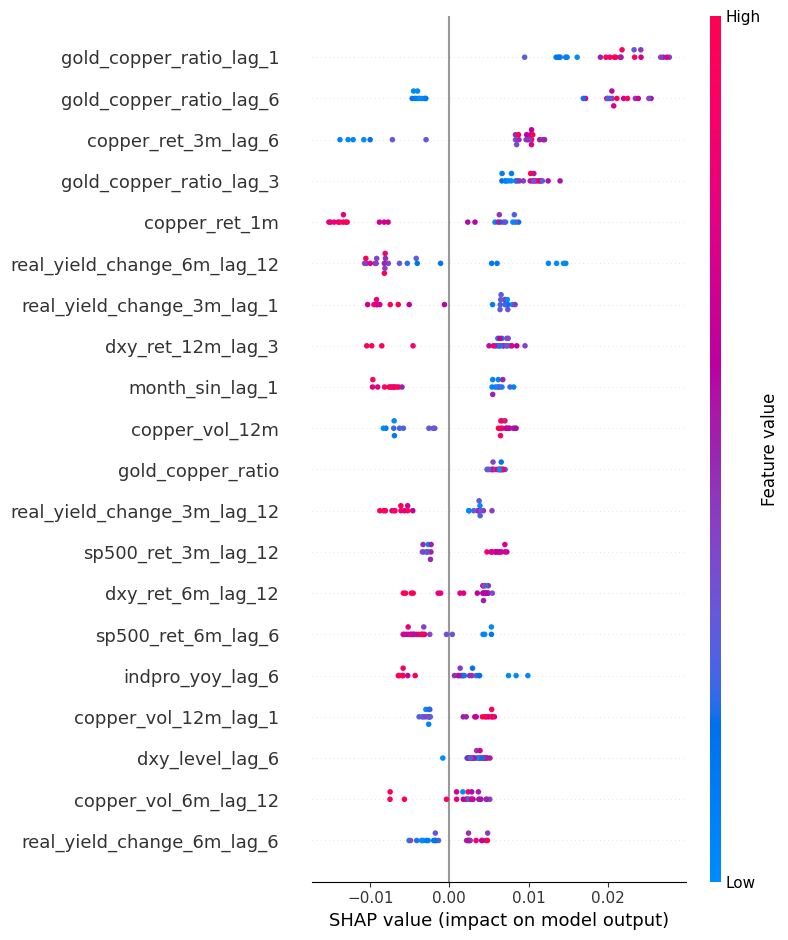

SHAP beeswarm saved to /kaggle/working/outputs_monthly/shap_beeswarm.png
Top 10 features by mean |SHAP|:
gold_copper_ratio_lag_1        0.020027
gold_copper_ratio_lag_6        0.014783
copper_ret_3m_lag_6            0.009967
gold_copper_ratio_lag_3        0.009682
copper_ret_1m                  0.009493
real_yield_change_6m_lag_12    0.008564
real_yield_change_3m_lag_1     0.007237
dxy_ret_12m_lag_3              0.007097
month_sin_lag_1                0.007006
copper_vol_12m                 0.006512


In [28]:
try:
    import shap, matplotlib.pyplot as plt
    shap.initjs()

    xgb_shap = make_xgb()
    xgb_shap.fit(X_dev_pruned, y_dev)
    explainer = shap.TreeExplainer(xgb_shap._model)
    shap_values = explainer.shap_values(X_hold_pruned)

    fig_shap = plot_shap_summary(shap_values, list(X_hold_pruned.columns), top_n=20)
    fig_shap.show()

    shap.summary_plot(shap_values, X_hold_pruned, max_display=20, show=False)
    plt.tight_layout()
    _bp = os.path.join(CFG['output_dir'], 'shap_beeswarm.png')
    plt.savefig(_bp, dpi=150, bbox_inches='tight'); plt.show()
    print(f'SHAP beeswarm saved to {_bp}')

    mean_abs_shap = pd.Series(
        np.abs(shap_values).mean(axis=0), index=X_hold_pruned.columns
    ).sort_values(ascending=False)
    print('Top 10 features by mean |SHAP|:')
    print(mean_abs_shap.head(10).to_string())
except Exception as e:
    print(f'SHAP skipped: {e}')


## 12. Interactive Plotly Visualisations

In [29]:
best_cv_df = cv_results[best_name]
fig_dashboard = plot_dashboard(df_aug, best_cv_df, model_name=best_name)
fig_dashboard.show()

# Rolling signal Sharpe of the SELECTED model (max signal_sharpe — same rule as the
# OOS cell above; this is the model that goes into forecast_summary.json).
best_oos_name = oos_summary['signal_sharpe'].idxmax()
oos_best = oos_results[best_oos_name]
signal_ret_oos = np.sign(oos_best['y_pred']) * oos_best['y_true']

# 12-month rolling window with monthly annualisation factor
roll_window = 12
rolling_sharpe = (
    signal_ret_oos.rolling(roll_window).mean() /
    signal_ret_oos.rolling(roll_window).std().replace(0, np.nan)
) * np.sqrt(CFG['periods_per_year'] / CFG['primary_horizon'])

fig_sharpe = go.Figure(go.Scatter(
    x=rolling_sharpe.index, y=rolling_sharpe,
    name='Rolling Sharpe (12m)', line=dict(color='#b87333'),
))
fig_sharpe.add_hline(y=0, line_width=1, line_dash='dash', line_color='grey')
fig_sharpe.update_layout(
    title=f'Rolling 12-Month Signal Sharpe — {best_oos_name} ({CFG["primary_horizon"]}m horizon)',
    template='plotly_white', yaxis_title='Annualised Sharpe ratio',
)
fig_sharpe.show()


## 13. Scenario Analysis

Scenarios over a 3-month horizon — credibly long enough for the macro shocks
modeled here to play out, unlike a 1-day variant.

In [30]:
latest_features = X_pruned_full.tail(1)
current_copper  = float(df_aug['copper_price'].iloc[-1])

scenario_model = EnsembleModel([make_xgb(), make_lgb()])
scenario_model.fit(X_dev_pruned, y_dev)

engine = ScenarioEngine(
    model=scenario_model,
    feature_template=latest_features,
    copper_price_current=current_copper,
    horizon=CFG['primary_horizon'],
)
print(f'Current copper price       : ${current_copper:,.0f}/t')
print(f'Baseline {CFG["primary_horizon"]}-month forecast: ${engine.base_price:,.0f}/t')

scenario_report = engine.report()
print('\n── Scenario Report (monthly model) ──')
print(scenario_report.to_string())

fig_tornado = plot_scenario_tornado(
    base_forecast=engine.base_price,
    scenario_results={row.Index: row.scenario_price for row in scenario_report.itertuples()},
)
fig_tornado.show()


WARNING | Shock target 'dxy_ret_22d' not in feature set — skipped.
WARNING | Shock target 'real_yield_change_22d' not in feature set — skipped.
WARNING | Shock target 'indpro_yoy' not in feature set — skipped.
WARNING | Shock target 'sp500_ret_22d' not in feature set — skipped.
INFO | Scenario 'bull_strong': base=13704  forecast=13704  delta=+0 (0.0%)
WARNING | Shock target 'dxy_ret_22d' not in feature set — skipped.
WARNING | Shock target 'real_yield_change_22d' not in feature set — skipped.
WARNING | Shock target 'indpro_yoy' not in feature set — skipped.
WARNING | Shock target 'sp500_ret_22d' not in feature set — skipped.
INFO | Scenario 'bear_strong': base=13704  forecast=13704  delta=+0 (0.0%)
WARNING | Shock target 'sp500_ret_22d' not in feature set — skipped.
WARNING | Shock target 'indpro_yoy' not in feature set — skipped.
WARNING | Shock target 'cny_usd_level' not in feature set — skipped.
INFO | Scenario 'china_demand_surge': base=13704  forecast=13704  delta=+0 (0.0%)
WARNIN

Current copper price       : $13,287/t
Baseline 3-month forecast: $13,704/t

── Scenario Report (monthly model) ──
                            base_price  scenario_price  delta  delta_pct
scenario                                                                
bull_strong                   13703.59        13703.59    0.0        0.0
bear_strong                   13703.59        13703.59    0.0        0.0
china_demand_surge            13703.59        13703.59    0.0        0.0
supply_disruption             13703.59        13703.59    0.0        0.0
comex_inventory_drop_40pct    13703.59        13703.59    0.0        0.0
high_inflation                13703.59        13703.59    0.0        0.0
us_tariff_shock               13703.59        13703.59    0.0        0.0


In [31]:
# DXY sensitivity sweep — uses dxy_ret_3m if present, else falls back to first
# available dxy return feature so it works regardless of the CFG['return_lags'] choice.
_dxy_candidates = [c for c in X_pruned_full.columns if c.startswith('dxy_ret_')]
if _dxy_candidates:
    sweep_col = next((c for c in _dxy_candidates if c.endswith('3m')), _dxy_candidates[0])
    dxy_shocks = np.linspace(-0.10, 0.10, 21)
    sweep_dxy  = engine.sweep(sweep_col, dxy_shocks.tolist(), label=f'{sweep_col} shock')
    fig_sweep  = go.Figure(go.Scatter(
        x=sweep_dxy['shock'], y=sweep_dxy['forecast_price'],
        mode='lines+markers', line=dict(color='#b87333'), name='Forecast price',
    ))
    fig_sweep.add_hline(y=engine.base_price, line_dash='dash', line_color='grey',
                        annotation_text='Baseline')
    fig_sweep.update_layout(
        title=f'Copper price sensitivity to {sweep_col}',
        xaxis_title=f'{sweep_col} shock (additive)',
        yaxis_title='Forecast Copper Price ($/t)',
        template='plotly_white',
    )
    fig_sweep.show()
else:
    print('No dxy_ret_* feature in pruned set — skipping DXY sweep.')

# Custom geopolitical / tariff shock (scaled to monthly magnitudes)
shock_kwargs = {}
for k, v in {'dxy_ret_3m': 0.04, 'sp500_ret_3m': -0.08,
             'copper_vol_3m': 0.05, 'real_yield_change_3m': 0.3}.items():
    if k in X_pruned_full.columns:
        shock_kwargs[k] = v
if shock_kwargs:
    result = engine.run('geo_tariff_shock', shocks=shock_kwargs)
    print('\nCustom scenario result:')
    for k, v in result.items():
        print(f'  {k}: {v}')
else:
    print('No matching shock features in pruned set — skipping custom scenario.')


INFO | Scenario 'geo_tariff_shock': base=13704  forecast=13705  delta=+1 (0.0%)



Custom scenario result:
  scenario: geo_tariff_shock
  base_price: 13703.59
  scenario_price: 13705.05
  delta: 1.46
  delta_pct: 0.01


## 14. Export Results

In [32]:
import json
from datetime import date

out_dir = CFG['output_dir']

forecast_df.to_csv(os.path.join(out_dir, 'forecast_multi_horizon.csv'))
ci_walk.reset_index().rename(columns={'index': 'date'}).to_csv(
    os.path.join(out_dir, 'forecast_ci_walk.csv'), index=False
)

for name, df_oos in oos_results.items():
    safe_name = name.replace(' ', '_').replace('(', '').replace(')', '').replace(',', '')
    df_oos.to_csv(os.path.join(out_dir, f'oos_{safe_name}.csv'))

oos_summary.to_csv(os.path.join(out_dir, 'model_comparison.csv'))
scenario_report.to_csv(os.path.join(out_dir, 'scenario_report.csv'))
coint_df.to_csv(os.path.join(out_dir, 'cointegration_results.csv'))

summary_json = {
    'generated_at':       date.today().isoformat(),
    'frequency':          'monthly',
    'current_price':      round(current_copper, 2),
    'primary_horizon_m':  CFG['primary_horizon'],
    'horizons_m':         CFG['horizons'],
    'baseline_forecast':  round(engine.base_price, 2),
    'best_model':         best_oos_name,
    'oos_metrics':        oos_metrics[best_oos_name],
    'multi_horizon_forecast': {int(k): {kk: float(vv) for kk, vv in v.items()}
                               for k, v in forecast_df.to_dict(orient='index').items()},
    'scenarios':          scenario_report.reset_index().to_dict(orient='records'),
}
with open(os.path.join(out_dir, 'forecast_summary.json'), 'w') as f:
    json.dump(summary_json, f, indent=2, default=float)

print(f'All outputs saved to {out_dir}/')
print('Files:', sorted(os.listdir(out_dir)))


All outputs saved to /kaggle/working/outputs_monthly/
Files: ['cointegration_results.csv', 'forecast_ci_walk.csv', 'forecast_multi_horizon.csv', 'forecast_summary.json', 'model_comparison.csv', 'oos_ARIMAX101.csv', 'oos_LightGBM.csv', 'oos_Linear_Ridge.csv', 'oos_Naive_RW.csv', 'oos_Prophet.csv', 'oos_StackingXGBoost+LightGBM+Prophet.csv', 'oos_XGBoost.csv', 'scenario_report.csv', 'shap_beeswarm.png']


---
## Email forecast pipeline

In [33]:
# ── Email forecast results after pipeline run ────────────────────────────────
import smtplib, os
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText
from email.mime.base import MIMEBase
from email import encoders


def send_email_with_attachments(sender_email, sender_password, receiver_email,
                                subject, body, attachments):
    msg = MIMEMultipart()
    msg['From']    = sender_email
    msg['To']      = receiver_email
    msg['Subject'] = subject
    msg.attach(MIMEText(body, 'plain'))

    for item in attachments:
        if isinstance(item, (tuple, list)):
            file_path, attached_name = item
        else:
            file_path, attached_name = item, None
        if not os.path.exists(file_path):
            print(f'  Skipping missing attachment: {file_path}')
            continue
        with open(file_path, 'rb') as f:
            part = MIMEBase('application', 'octet-stream')
            part.set_payload(f.read())
        encoders.encode_base64(part)
        if attached_name is None:
            attached_name = os.path.basename(file_path)
        elif not os.path.splitext(attached_name)[1]:
            attached_name += os.path.splitext(file_path)[1]
        part.add_header('Content-Disposition',
                        f'attachment; filename={attached_name}')
        msg.attach(part)

    with smtplib.SMTP_SSL('smtp.gmail.com', 465) as server:
        server.login(sender_email, sender_password)
        server.send_message(msg)
    print(f'Email sent to {receiver_email}')


def save_figure(fig, png_path):
    try:
        fig.write_image(png_path, scale=2)
        print(f'Saved {os.path.basename(png_path)}')
        return png_path
    except Exception as e:
        print(f'Could not save {os.path.basename(png_path)}: {e}')
        html_path = png_path.replace('.png', '.html')
        fig.write_html(html_path)
        print(f'  Saved fallback {os.path.basename(html_path)}')
        return html_path


def _safe_model_name(name):
    return (name.replace(' ', '_').replace('(', '').replace(')', '')
                .replace('/', '_').replace('+', 'plus').replace(',', ''))


# ── Resolve the forecast horizon to a monthly label ──────────────────────────
_h          = CFG['primary_horizon']
horizon_label = f'{_h} month' + ('s' if _h != 1 else '')
horizon_tag   = f'{_h}m'

as_of_dt    = df_aug.index[-1]
target_dt   = as_of_dt + pd.DateOffset(months=_h)
as_of_str   = as_of_dt.date().isoformat()
target_str  = target_dt.date().isoformat()

out_dir = CFG['output_dir']
saved_fc   = save_figure(fig_fc,  os.path.join(out_dir, 'forecast_ci.png'))
saved_cmp  = save_figure(fig_cmp, os.path.join(out_dir, 'model_comparison.png'))
fig_best   = plot_cv_results(oos_results[best_oos_name], model_name=f'{best_oos_name} (OOS)')
saved_best = save_figure(fig_best, os.path.join(out_dir, 'best_model_oos.png'))

_safe_best   = _safe_model_name(best_oos_name)
_attachments = [
    (saved_fc,  f'forecast_ci_{horizon_tag}_QuantileForecaster.png'),
    (saved_cmp, f'model_comparison_oos_{horizon_tag}_all_candidates.png'),
    (saved_best, f'oos_folds_{_safe_best}_{horizon_tag}.png'),
    (os.path.join(out_dir, 'shap_beeswarm.png'),
     'shap_beeswarm_XGBoost_explainability.png'),
]


# ── Load email credentials from Kaggle Secrets ───────────────────────────────
try:
    from kaggle_secrets import UserSecretsClient
    _secrets        = UserSecretsClient()
    sender_email    = _secrets.get_secret('GMAIL_ADDRESS')
    sender_password = _secrets.get_secret('GMAIL_APP_PASSWORD')
except Exception as e:
    raise RuntimeError(f'Email secrets not found — add GMAIL_ADDRESS and GMAIL_APP_PASSWORD to Kaggle Secrets. ({e})')


_sel = oos_summary.loc[best_oos_name]

# Multi-horizon forecast block in the body
_mh_lines = []
for h_row in forecast_df.reset_index().itertuples():
    _mh_lines.append(
        f"  {h_row.horizon_months}m: median ${h_row.median:,.0f}/t  "
        f"(80% CI ${h_row.lower:,.0f} – ${h_row.upper:,.0f})"
    )
_mh_block = '\n'.join(_mh_lines)

email_body = (
    f'Copper Forecast Pipeline (MONTHLY) complete.\n'
    f'Forecast horizon : {horizon_label}\n'
    f'Data as of       : {as_of_str}\n'
    f'Forecast for     : {target_str}  (= as-of + {_h} months)\n'
    f'\n'
    f'Selected model   : {best_oos_name}  (max OOS signal_sharpe — used for the forecast)\n'
    f'  signal_sharpe        : {_sel["signal_sharpe"]:+.3f}\n'
    f'  directional_accuracy : {_sel["directional_accuracy"]:.3f}\n'
    f'  rmse_skill vs Naive  : {_sel["rmse_skill"]:+.4f}\n'
    f'  rmse                 : {_sel["rmse"]:.4f}\n'
    f'CV-stage winner  : {best_name}  (informational only)\n'
    f'\n'
    f'Current price    : ${current_copper:,.0f}/t\n'
    f'Baseline forecast: ${engine.base_price:,.0f}/t  ({horizon_label})\n'
    f'\n'
    f'Multi-horizon forecast (median + 80% CI):\n{_mh_block}\n'
    f'\n'
    f'Attachments (model annotated in each filename):\n'
    f'  - forecast_ci_{horizon_tag}_QuantileForecaster.png (CI walk over the holdout)\n'
    f'  - model_comparison_oos_{horizon_tag}_all_candidates.png\n'
    f'  - oos_folds_{_safe_best}_{horizon_tag}.png\n'
    f'  - shap_beeswarm_XGBoost_explainability.png\n'
)

send_email_with_attachments(
    sender_email    = sender_email,
    sender_password = sender_password,
    receiver_email  = sender_email,
    subject         = f'Copper Forecast (Monthly) — {horizon_label} — {best_oos_name} ({as_of_str})',
    body            = email_body,
    attachments     = _attachments,
)


Saved forecast_ci.png
Saved model_comparison.png
Saved best_model_oos.png
Email sent to ferhat00@gmail.com
